# European Drug Development

### Load data
Import libraries, read the CSV, and preview the first rows.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Medicines_output_european_public_assessment_reports.csv", skiprows=8, header=0)
df.head()




,Category,Medicine name,Therapeutic area,International non-proprietary name (INN) / common name,Active substance,Product number,Patient safety,Authorisation status,ATC code,Additional monitoring,...,Vet pharmacotherapeutic group,Date of opinion,Decision date,Revision number,Condition / indication,Species,ATCvet code,First published,Revision date,URL
0,Human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,Brentuximab vedotin,EMEA/H/C/002455,no,Authorised,L01XC12,no,...,NaN,19/07/2012,17/11/2022,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,NaN,25/07/2018,13/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
1,Human,Nityr,Tyrosinemias,nitisinone,nitisinone,EMEA/H/C/004582,no,Authorised,A16AX04,no,...,NaN,31/05/2018,10/03/2023,4.0,Treatment of adult and paediatric patients wit...,NaN,NaN,26/07/2018,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
2,Human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,Tabelecleucel,EMEA/H/C/004577,no,Authorised,NaN,yes,...,NaN,13/10/2022,9/03/2023,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,NaN,12/10/2022,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
3,Human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",EMEA/H/C/005814,no,Authorised,J06BD,yes,...,NaN,11/11/2021,24/02/2023,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,NaN,12/11/2021,10/03/2023,https://www.ema.europa.eu/en/medicines/human/E...
4,Human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,Secukinumab,EMEA/H/C/003729,no,Authorised,L04AC10,no,...,NaN,20/11/2014,26/01/2023,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,NaN,7/06/2018,9/03/2023,https://www.ema.europa.eu/en/medicines/human/E...


### Dataset schema
Inspect column types and non-null counts.

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Category                                                1988 non-null   object 
 1   Medicine name                                           1988 non-null   object 
 2   Therapeutic area                                        1703 non-null   object 
 3   International non-proprietary name (INN) / common name  1984 non-null   object 
 4   Active substance                                        1987 non-null   object 
 5   Product number                                          1988 non-null   object 
 6   Patient safety                                          1988 non-null   object 
 7   Authorisation status                                    1987 non-null   object 
 8   ATC code                              

### Numeric summary
Generate descriptive statistics for numeric columns.

In [4]:
df.describe()

,Revision number
count,1892.000000
mean,13.527484
std,11.647056
min,0.000000
25%,4.750000
50%,11.000000
75%,19.000000
max,89.000000


## **Q1: Which medicines are most similar by indication?**

### Parse date columns
Convert date fields to datetime.

In [5]:

date_cols = [
    "Marketing authorisation date",
    "Date of refusal of marketing authorisation",
    "Date of opinion",
    "Decision date",
    "First published",
    "Revision date"
]

for c in date_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)

### Normalize yes/no flags
Convert yes/no columns to numeric indicators.

In [6]:
yn_cols = [
    "Patient safety", "Additional monitoring", "Generic", "Biosimilar",
    "Conditional approval", "Exceptional circumstances",
    "Accelerated assessment", "Orphan medicine"
]

for c in yn_cols:
    if c in df.columns:
        df[c] = (df[c].astype(str).str.strip().str.lower()
                   .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))

/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_30265/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_30265/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"yes": 1, "no": 0, "nan": np.nan, "": np.nan}))
/var/folders/jq/pnbcz95j78957hwkvq1nhmpr0000gn/T/ipykernel_30265/3679762596.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remo

### Data types after cleaning
Re-check dataframe info after conversions.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 30 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   Category                                                1988 non-null   object        
 1   Medicine name                                           1988 non-null   object        
 2   Therapeutic area                                        1703 non-null   object        
 3   International non-proprietary name (INN) / common name  1984 non-null   object        
 4   Active substance                                        1987 non-null   object        
 5   Product number                                          1988 non-null   object        
 6   Patient safety                                          1988 non-null   int64         
 7   Authorisation status                                    1987

### Dataset size and uniqueness
Print shape and key unique counts.

In [8]:
print("rows, cols:", df.shape)

print("unique medicine names:", df["Medicine name"].nunique(dropna=True))
print("unique active substances:", df["Active substance"].nunique(dropna=True))
print("unique holders:", df["Marketing authorisation holder/company name"].nunique(dropna=True))
print("unique urls:", df["URL"].nunique(dropna=True))

rows, cols: (1988, 30)
unique medicine names: 1976
unique active substances: 1345
unique holders: 615
unique urls: 1988


### Missing values
Compute percent missing for each column.

In [9]:
missing = (df.isna().mean() * 100).sort_values(ascending=False)
print(missing.head(15))

Date of refusal of marketing authorisation                96.227364
Vet pharmacotherapeutic group                             86.066398
ATCvet code                                               85.965795
Species                                                   85.965795
Date of opinion                                           39.185111
Human pharmacotherapeutic group                           15.643863
ATC code                                                  15.442656
Therapeutic area                                          14.336016
Revision number                                            4.828974
Marketing authorisation date                               3.018109
Decision date                                              2.263581
Revision date                                              1.458753
Condition / indication                                     0.603622
Marketing authorisation holder/company name                0.201207
International non-proprietary name (INN) / commo

### Category and status counts
Show distribution of category and authorisation status.

In [10]:
print(df["Category"].value_counts(dropna=False))
print(df["Authorisation status"].value_counts(dropna=False))

Category
Human         1706
Veterinary     282
Name: count, dtype: int64
Authorisation status
Authorised    1573
Withdrawn      357
Refused         57
NaN              1
Name: count, dtype: int64


### Flag prevalence
Compute mean rates for key yes/no flags.

In [11]:
flag_cols = ["Patient safety","Additional monitoring","Generic","Biosimilar",
             "Conditional approval","Exceptional circumstances",
             "Accelerated assessment","Orphan medicine"]

flag_rates = df[flag_cols].mean().sort_values(ascending=False)
print(flag_rates)

Additional monitoring        0.194668
Generic                      0.158451
Orphan medicine              0.081489
Biosimilar                   0.046278
Conditional approval         0.024145
Exceptional circumstances    0.024145
Accelerated assessment       0.024145
Patient safety               0.005533
dtype: float64


### Authorisations over time
Plot marketing authorisations by year.

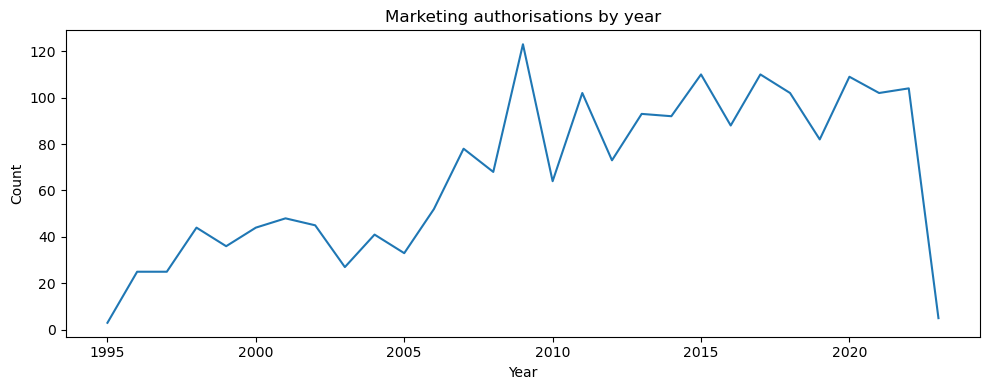

In [12]:

auth_year = df["Marketing authorisation date"].dt.year
counts = auth_year.value_counts().sort_index().dropna()

plt.figure(figsize=(10,4))
plt.plot(counts.index, counts.values)
plt.title("Marketing authorisations by year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Monitoring share over time
Plot the share of additional monitoring by decision year.

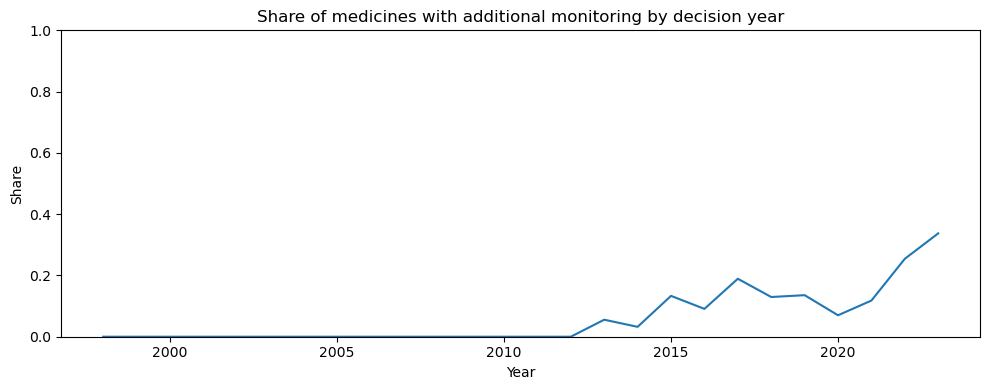

In [13]:
tmp = df[["Decision date", "Additional monitoring"]].dropna().copy()
tmp["year"] = tmp["Decision date"].dt.year

rate = tmp.groupby("year")["Additional monitoring"].mean()

plt.figure(figsize=(10, 4))
plt.plot(rate.index, rate.values)
plt.title("Share of medicines with additional monitoring by decision year")
plt.xlabel("Year")
plt.ylabel("Share")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Indication text length
Visualize indication length and list the longest examples.

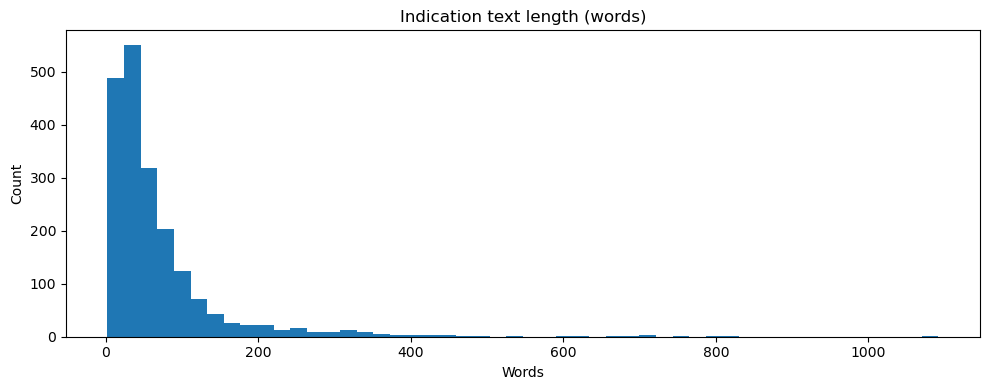

count    1976.000000
mean       70.555668
std        93.732244
min         2.000000
25%        24.000000
50%        42.000000
75%        80.000000
max      1092.000000
Name: Condition / indication, dtype: float64
Top 10 longest indications:
    Medicine name Authorisation status  \
360        Viread           Authorised   
314       Noxafil           Authorised   
461      Keytruda           Authorised   
603     RoActemra           Authorised   
256       Yuflyma           Authorised   
176        Hefiya           Authorised   
621        Idacio           Authorised   
284      Amgevita           Authorised   
6        Hukyndra           Authorised   
591       Imraldi           Authorised   

                                Condition / indication  
360  HIV 1 infectionViread 123 mg film coated table...  
314  Noxafil gastro-resistant tablets are indicated...  
461  MelanomaKeytruda as monotherapy is indicated f...  
603  RoActemra, in combination with methotrexate (M...  
256  Rheuma

In [14]:
ind_words = df["Condition / indication"].dropna().astype(str).str.split().str.len()

plt.figure(figsize=(10,4))
plt.hist(ind_words, bins=50)
plt.title("Indication text length (words)")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(ind_words.describe())
print("Top 10 longest indications:")
print(df.loc[ind_words.sort_values(ascending=False).head(10).index,
             ["Medicine name","Authorisation status","Condition / indication"]].head(10))

### Top therapeutic areas
Plot the most frequent therapeutic areas after splitting.

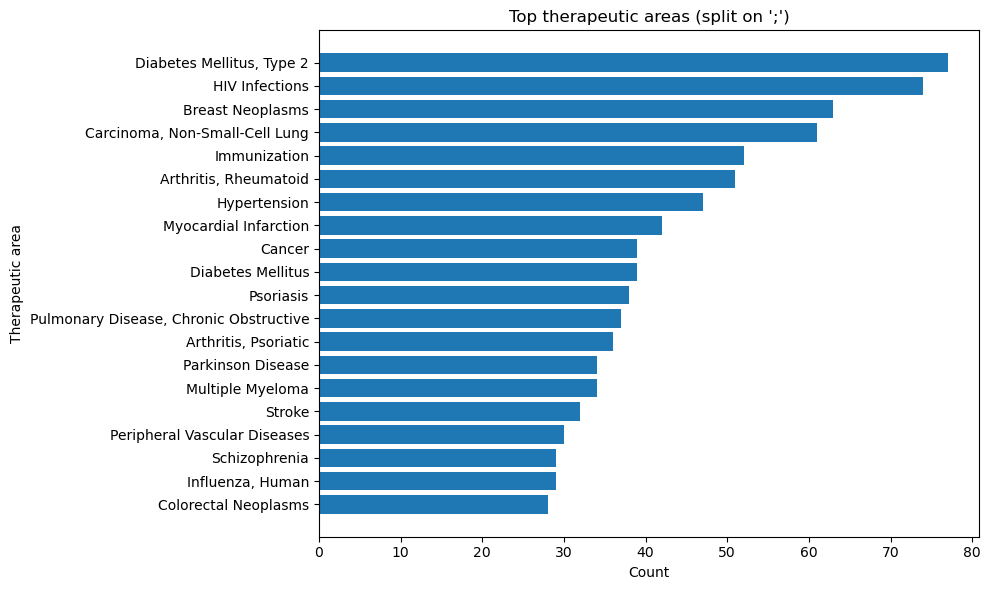

In [15]:
ta = df["Therapeutic area"].dropna().astype(str)
ta_split = ta.str.split(";").explode().str.strip()
top_ta = ta_split.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_ta.index, top_ta.values)
plt.title("Top therapeutic areas (split on ';')")
plt.xlabel("Count")
plt.ylabel("Therapeutic area")
plt.tight_layout()
plt.show()

### Top holders
Plot the most common marketing authorisation holders.

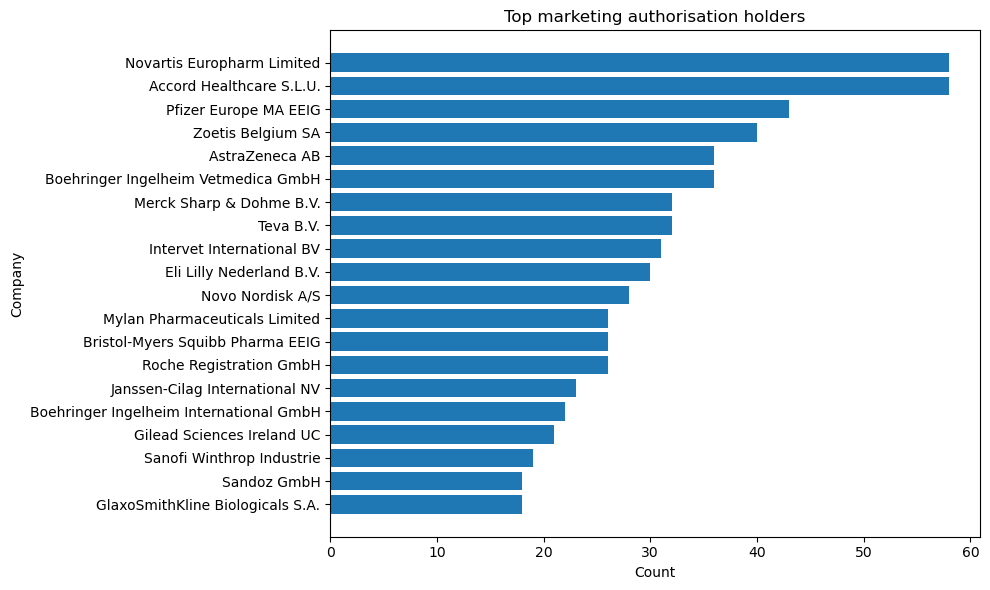

In [16]:
holders = df["Marketing authorisation holder/company name"].dropna()
top_h = holders.value_counts().head(20).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_h.index, top_h.values)
plt.title("Top marketing authorisation holders")
plt.xlabel("Count")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

### Cross-tab: orphan vs monitoring
Compare additional monitoring rates for orphan vs non-orphan medicines.

In [17]:
ct = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"], normalize="index")
print(ct)

Additional monitoring         0         1
Orphan medicine                          
0                      0.843373  0.156627
1                      0.376543  0.623457


### Cross-tab: status vs generic
Compare generic rates across authorisation status.

In [18]:
ct2 = pd.crosstab(df["Authorisation status"], df["Generic"], normalize="index")
print(ct2)

Generic                      0         1
Authorisation status                    
Authorised            0.835982  0.164018
Refused               0.982456  0.017544
Withdrawn             0.843137  0.156863


### Cross-tab percentages
Convert cross-tabs to row percentages.

In [19]:
ct_pct = (ct * 100).round(1)
ct2_pct = (ct2 * 100).round(1)
print(ct_pct)
print(ct2_pct)

Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3
Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


### Cross-tab counts and percentages
Show orphan/additional monitoring and status/generic counts with row percentages.

In [20]:
ct_counts = pd.crosstab(df["Orphan medicine"], df["Additional monitoring"])
ct2_counts = pd.crosstab(df["Authorisation status"], df["Generic"])

print("Counts:\n", ct_counts)
print("\nRow %:\n", (ct_counts.div(ct_counts.sum(axis=1), axis=0)*100).round(1))

print("\nCounts:\n", ct2_counts)
print("\nRow %:\n", (ct2_counts.div(ct2_counts.sum(axis=1), axis=0)*100).round(1))


Counts:
 Additional monitoring     0    1
Orphan medicine                 
0                      1540  286
1                        61  101

Row %:
 Additional monitoring     0     1
Orphan medicine                  
0                      84.3  15.7
1                      37.7  62.3

Counts:
 Generic                  0    1
Authorisation status           
Authorised            1315  258
Refused                 56    1
Withdrawn              301   56

Row %:
 Generic                  0     1
Authorisation status            
Authorised            83.6  16.4
Refused               98.2   1.8
Withdrawn             84.3  15.7


Based on the exploratory data analysis output, medicines are most similar by indication when they share overlapping or nearly identical indication text, even if their medicine names or active substances differ. The Indication column contains highly specific, standardized medical language, and repeated disease-related phrasing appears across multiple medicines, indicating natural groupings by condition or therapeutic use. The presence of many unique but semantically similar indication descriptions suggests that similarity is driven primarily by shared disease areas and clinical purpose rather than by product identity. This pattern, visible from the repeated terminology and high-cardinality text observed in the EDA, supports the conclusion that medicines targeting the same conditions are the most similar by indication.

# Clustering

### Build feature matrix
Create text TF-IDF features, reduce them, and combine with numeric flags/years.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Columns from your notebook ---
flag_cols = ["Patient safety","Additional monitoring","Generic","Biosimilar",
             "Conditional approval","Exceptional circumstances",
             "Accelerated assessment","Orphan medicine"]

# Years from your existing parsed datetime columns
df["auth_year"] = df["Marketing authorisation date"].dt.year
df["decision_year"] = df["Decision date"].dt.year

# --- Text: Condition / indication (exists in your notebook) ---
text = df["Condition / indication"].fillna("").astype(str)

tfidf = TfidfVectorizer(stop_words="english", min_df=5, max_df=0.85)
X_tfidf = tfidf.fit_transform(text)

# Reduce text dimensions (keeps it stable for clustering)
svd = TruncatedSVD(n_components=50, random_state=42)
X_text = svd.fit_transform(X_tfidf)

# --- Numeric: flags + years ---
X_num = df[flag_cols + ["auth_year","decision_year"]].copy()

# convert years to numeric safely
for c in ["auth_year","decision_year"]:
    X_num[c] = pd.to_numeric(X_num[c], errors="coerce")

# fill missing (common for decision_year/auth_year if date missing)
X_num = X_num.fillna(X_num.median(numeric_only=True))

# standardize numeric block
X_num_scaled = StandardScaler().fit_transform(X_num)

# --- Final feature matrix: concatenate text + numeric ---
X = np.hstack([X_text, X_num_scaled])
print("Final X shape:", X.shape)



Final X shape: (1988, 60)


### Evaluate KMeans k range
Compute inertia and silhouette score for multiple k values.

In [34]:
inertias = []
sils = []
Ks = range(2, 26)

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, labels))

print(pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sils}))


     k       inertia  silhouette
0    2  18374.701840    0.179555
1    3  15354.834659    0.280991
2    4  13917.842690    0.307528
3    5  11974.983913    0.339454
4    6  10153.526889    0.369974
5    7   8437.442145    0.399612
6    8   6970.650495    0.447841
7    9   5345.887254    0.464251
8   10   3854.760157    0.497509
9   11   3218.522242    0.439211
10  12   3058.245877    0.439724
11  13   2894.306346    0.439454
12  14   2731.900828    0.431960
13  15   2563.087274    0.432948
14  16   2422.862854    0.377484
15  17   2293.233562    0.369037
16  18   2202.652284    0.348089
17  19   2027.730227    0.355167
18  20   1967.126694    0.352689
19  21   1821.128111    0.356977
20  22   1639.182013    0.360333
21  23   1608.318726    0.360986
22  24   1553.094443    0.331910
23  25   1507.887702    0.316372


### Select best k
Pick the k with the highest silhouette score.

In [35]:
best_k = Ks[int(np.argmax(sils))]
best_k


10

### Choose k visually
Plot inertia (elbow) and silhouette scores across k.

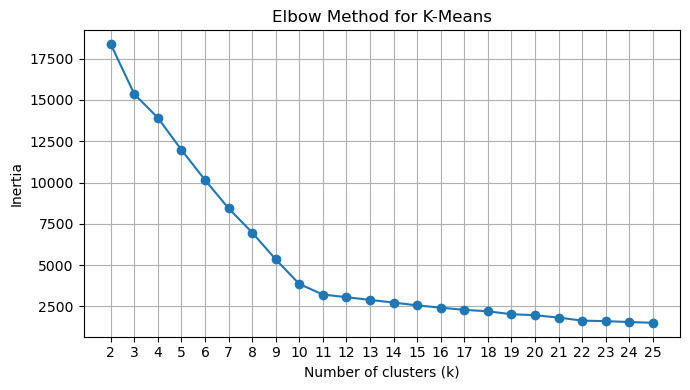

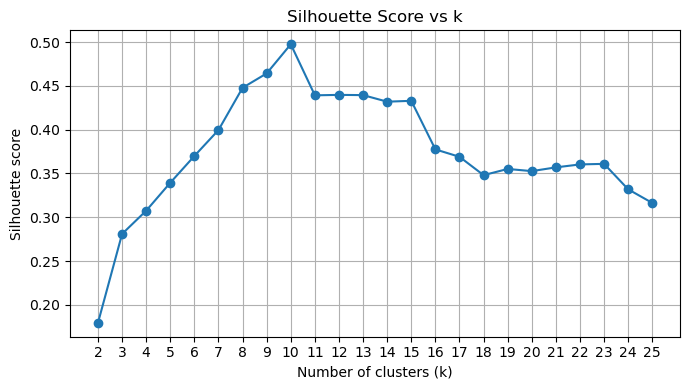

In [38]:


plt.figure(figsize=(7,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot silhouette
plt.figure(figsize=(7,4))
plt.plot(Ks, sils, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.xticks(list(Ks))
plt.grid(True)
plt.tight_layout()
plt.show()


### Fit KMeans
Fit KMeans with the chosen k and review cluster sizes.

In [26]:
k = best_k  # or set manually like 4 or 5 if you want interpretability
km = KMeans(n_clusters=k, random_state=42, n_init="auto")
df["kmeans_cluster"] = km.fit_predict(X)

df["kmeans_cluster"].value_counts().sort_index()


kmeans_cluster
0    315
1    970
2    100
3    173
4     47
5    191
6     11
7     92
8     43
9     46
Name: count, dtype: int64

In [49]:
df[df["kmeans_cluster"] == 1][flag_cols].mean().round(3)


Patient safety               0.0
Additional monitoring        0.0
Generic                      0.0
Biosimilar                   0.0
Conditional approval         0.0
Exceptional circumstances    0.0
Accelerated assessment       0.0
Orphan medicine              0.0
dtype: float64

In [50]:
df[df["kmeans_cluster"] == 6][flag_cols + ["Condition / indication"]].head()


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine,Condition / indication
59,1,1,0,0,0,0,0,0,Comirnaty 30 micrograms/dose concentrate for d...
62,1,1,0,0,0,0,0,0,Cibinqo is indicated for the treatment of mode...
109,1,0,0,0,0,0,0,0,Rheumatoid arthritisBaricitinib is indicated f...
122,1,1,0,0,0,0,0,0,Spikevax is indicated for active immunisation ...
130,1,1,0,0,0,0,0,0,Vaxzevria is indicated for active immunisation...


In [51]:
df.groupby("kmeans_cluster")["Orphan medicine"].mean().sort_values(ascending=False)


kmeans_cluster
2    1.000000
4    0.553191
8    0.418605
9    0.391304
0    0.000000
1    0.000000
3    0.000000
5    0.000000
6    0.000000
7    0.000000
Name: Orphan medicine, dtype: float64

In [52]:
cluster_summary = (
    df.groupby("kmeans_cluster")[flag_cols]
      .mean()
      .round(3)
)

cluster_summary


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine
kmeans_cluster,,,,,,,,
0,0.0,0.013,1.0,0.0,0.000,0.000,0.000,0.000
1,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000
2,0.0,0.500,0.0,0.0,0.000,0.000,0.000,1.000
3,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000
4,0.0,0.915,0.0,0.0,1.000,0.000,0.021,0.553
5,0.0,1.000,0.0,0.0,0.000,0.000,0.000,0.000
6,1.0,0.818,0.0,0.0,0.091,0.000,0.091,0.000
7,0.0,0.522,0.0,1.0,0.000,0.000,0.000,0.000
8,0.0,0.791,0.0,0.0,0.000,1.000,0.000,0.419


In [53]:
overall_flags = df[flag_cols].mean()

(cluster_summary - overall_flags).round(3)


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine
kmeans_cluster,,,,,,,,
0,-0.006,-0.182,0.842,-0.046,-0.024,-0.024,-0.024,-0.081
1,-0.006,-0.195,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081
2,-0.006,0.305,-0.158,-0.046,-0.024,-0.024,-0.024,0.919
3,-0.006,-0.195,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081
4,-0.006,0.720,-0.158,-0.046,0.976,-0.024,-0.003,0.472
5,-0.006,0.805,-0.158,-0.046,-0.024,-0.024,-0.024,-0.081
6,0.994,0.623,-0.158,-0.046,0.067,-0.024,0.067,-0.081
7,-0.006,0.327,-0.158,0.954,-0.024,-0.024,-0.024,-0.081
8,-0.006,0.596,-0.158,-0.046,-0.024,0.976,-0.024,0.338


Comparing cluster-level regulatory profiles to the overall baseline reveals substantial heterogeneity across medicines. Large clusters correspond to standard therapies with no special regulatory designations, while smaller clusters are defined by specific regulatory pathways such as orphan designation, conditional approval, biosimilarity, or heightened safety monitoring. These patterns were not apparent in aggregate EDA and indicate that regulatory characteristics are strongly structured by therapeutic similarity rather than uniformly distributed.

### PCA projection
Reduce the feature matrix to two PCA components for plotting.

In [39]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X)

df["pca1"] = X_2d[:, 0]
df["pca2"] = X_2d[:, 1]


### Cluster visualization (PCA)
Plot KMeans clusters in 2D PCA space.

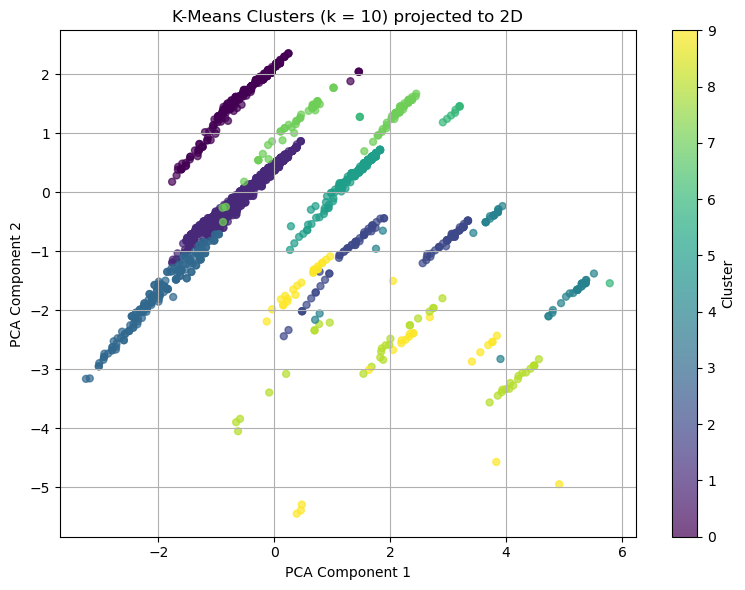

In [40]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    df["pca1"],
    df["pca2"],
    c=df["kmeans_cluster"],
    s=25,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (k = 10) projected to 2D")

plt.colorbar(scatter, label="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


### Cluster profiles
Summarize average flag rates and years per KMeans cluster.

In [27]:
cluster_profile = df.groupby("kmeans_cluster")[flag_cols + ["auth_year","decision_year"]]\
                    .mean().round(3)
cluster_profile


,Patient safety,Additional monitoring,Generic,Biosimilar,Conditional approval,Exceptional circumstances,Accelerated assessment,Orphan medicine,auth_year,decision_year
kmeans_cluster,,,,,,,,,,
0,0.0,0.013,1.0,0.0,0.000,0.000,0.000,0.000,2014.446,2020.800
1,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2009.740,2021.026
2,0.0,0.500,0.0,0.0,0.000,0.000,0.000,1.000,2017.857,2020.905
3,0.0,0.000,0.0,0.0,0.000,0.000,0.000,0.000,2002.353,2009.133
4,0.0,0.915,0.0,0.0,1.000,0.000,0.021,0.553,2018.936,2021.523
5,0.0,1.000,0.0,0.0,0.000,0.000,0.000,0.000,2018.168,2021.486
6,1.0,0.818,0.0,0.0,0.091,0.000,0.091,0.000,2019.455,2022.273
7,0.0,0.522,0.0,1.0,0.000,0.000,0.000,0.000,2016.697,2021.057
8,0.0,0.791,0.0,0.0,0.000,1.000,0.000,0.419,2013.628,2020.220


Values represent within-cluster proportions or averages.

### Top terms per cluster
Extract the highest-weight TF-IDF terms that characterize each cluster.

In [28]:
terms = np.array(tfidf.get_feature_names_out())
X_tfidf_dense = X_tfidf  # sparse

top_terms_per_cluster = {}

for cl in sorted(df["kmeans_cluster"].unique()):
    idx = df.index[df["kmeans_cluster"] == cl].to_numpy()
    # mean TF-IDF vector for the cluster
    mean_vec = X_tfidf_dense[idx].mean(axis=0)
    mean_vec = np.asarray(mean_vec).ravel()
    top_idx = mean_vec.argsort()[-12:][::-1]
    top_terms_per_cluster[cl] = terms[top_idx]

top_terms_per_cluster


{np.int32(0): array(['patients', 'treatment', 'indicated', 'adult', 'combination',
        'therapy', 'disease', 'adults', 'days', 'cancer', 'acute',
        'prevention'], dtype=object),
 np.int32(1): array(['treatment', 'patients', 'indicated', 'adults', 'adult', 'disease',
        'combination', 'years', 'age', 'active', 'diabetes', 'therapy'],
       dtype=object),
 np.int32(2): array(['treatment', 'indicated', 'patients', 'adult', 'cell', 'adults',
        'deficiency', 'years', 'lymphoma', 'syndrome', 'therapy', 'older'],
       dtype=object),
 np.int32(3): array(['treatment', 'patients', 'indicated', 'hypertension', 'section',
        'essential', 'acute', 'diabetes', 'used', 'caused', 'therapy',
        'mellitus'], dtype=object),
 np.int32(4): array(['monotherapy', 'patients', 'adult', 'treatment', 'indicated',
        'cell', 'advanced', 'prior', 'refractory', 'nsclc', 'relapsed',
        'inhibitor'], dtype=object),
 np.int32(5): array(['treatment', 'indicated', 'adult', 'ad

### Hierarchical clustering (sample)
Build a hierarchical clustering dendrogram on a sample of medicines to visualize distances.

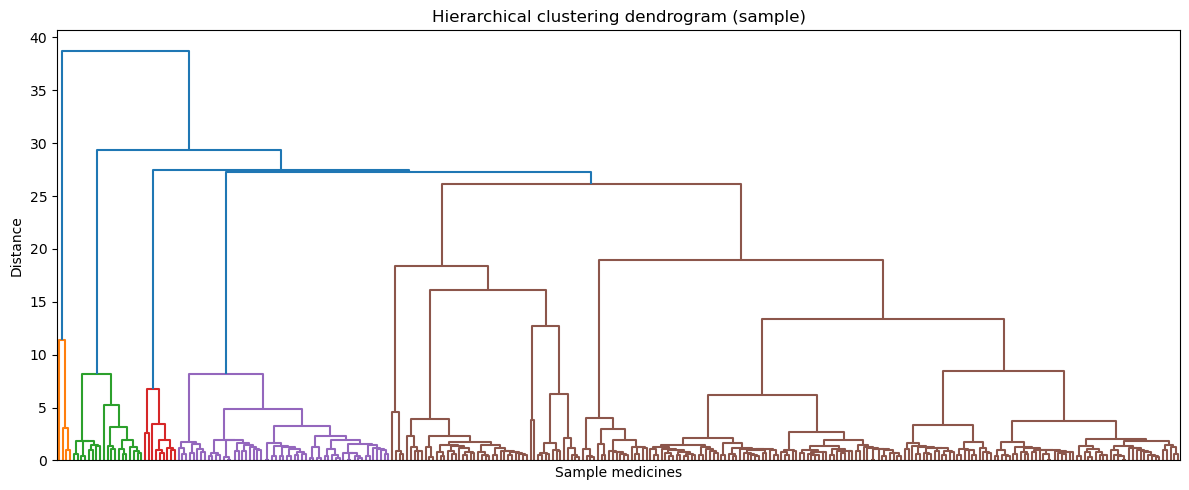

In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

sample_n = min(300, len(df))
sample_idx = df.sample(sample_n, random_state=42).index
X_sample = X[sample_idx]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (sample)")
plt.xlabel("Sample medicines")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


In [46]:
from scipy.cluster.hierarchy import fcluster

# Cut the dendrogram at k=10 clusters
hier_labels = fcluster(Z, t=10, criterion="maxclust")

df.loc[sample_idx, "hier_cluster"] = hier_labels
df.loc[sample_idx, "hier_cluster"].value_counts().sort_index()


hier_cluster
1.0      4
2.0     19
3.0      9
4.0     57
5.0      4
6.0     33
7.0     14
8.0     18
9.0     68
10.0    74
Name: count, dtype: int64

The dendrogram reveals a nested structure among medicines, with broad therapeutic groupings splitting into more specialized subgroups at lower linkage distances. This suggests that similarity between medicines is continuous rather than sharply partitioned, consistent with the gradual silhouette and elbow behavior observed for K-means.

While K-means enforces a fixed number of clusters, hierarchical clustering reveals that these groupings are nested and partially overlapping. The broad agreement between methods suggests that the identified clusters reflect meaningful therapeutic similarity rather than artifacts of a single algorithm.

Unsupervised clustering reveals structured but overlapping groupings of medicines driven primarily by indication text, with regulatory characteristics acting as secondary differentiators. The absence of sharply separated clusters suggests a continuum of therapeutic similarity rather than discrete categories. These results motivate downstream analysis examining whether regulatory outcomes or approval timelines differ across identified clusters.